# 🇻🇳 Báo cáo Chiến lược GDP Việt Nam: Tầm nhìn 2030
**Dự án:** GDP-Analyst | **Chuyên gia:** Đội ngũ Phân tích Dữ liệu Chiến lược

## Giới thiệu
Notebook này tổng hợp toàn bộ kết quả phân tích từ giai đoạn tiền xử lý, chẩn đoán điểm gãy kinh tế đến dự báo tương lai. Đây là tài liệu kỹ thuật cuối cùng hỗ trợ cho các quyết sách chiến lược.

## 1. Toàn cảnh Tăng trưởng (Historical Overview)
Chúng ta nhìn lại hành trình tăng trưởng qua 3 thập kỷ.

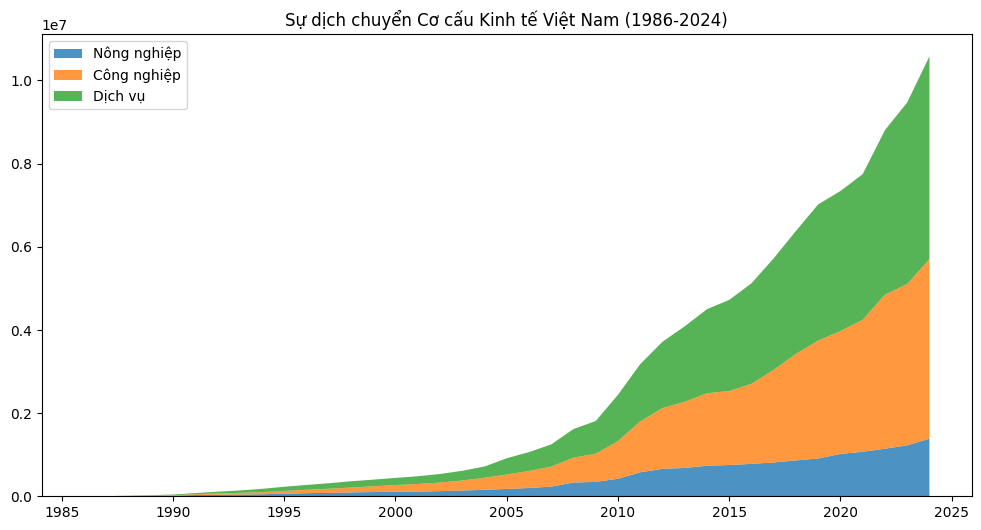

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'../data/processed/gdp_sectors_processed.csv')
df.columns = ['Year', 'Total', 'Agri', 'Indu', 'Serv', 'Tax']

plt.figure(figsize=(12, 6))
plt.stackplot(df['Year'], df['Agri'], df['Indu'], df['Serv'], 
              labels=['Nông nghiệp', 'Công nghiệp', 'Dịch vụ'], alpha=0.8)
plt.title('Sự dịch chuyển Cơ cấu Kinh tế Việt Nam (1986-2024)')
plt.legend(loc='upper left')
plt.show()

## 2. Điểm gãy & Sức chống chịu (Diagnostic Analysis)
Phân tích tại các mốc khủng hoảng để hiểu động cơ nào dẫn đầu sự sụt giảm.

In [2]:
# Tính toán đóng góp vào tăng trưởng (p.p)
df['Growth'] = df['Total'].pct_change() * 100
crisis_years = [1998, 2008, 2020]
crisis_df = df[df['Year'].isin(crisis_years)]

print("Phân tích tại các điểm gãy:")
crisis_df[['Year', 'Growth', 'Indu', 'Serv']]

Phân tích tại các điểm gãy:


,Year,Growth,Indu,Serv
12,1998,15.111774,117299.0,150645.0
22,2008,29.618799,599193.0,686968.0
34,2020,4.374940,2955806.0,3365059.9


## 3. Chất lượng Tăng trưởng (TFP Analysis)
Sự dịch chuyển từ thâm dụng vốn sang thâm dụng năng suất.

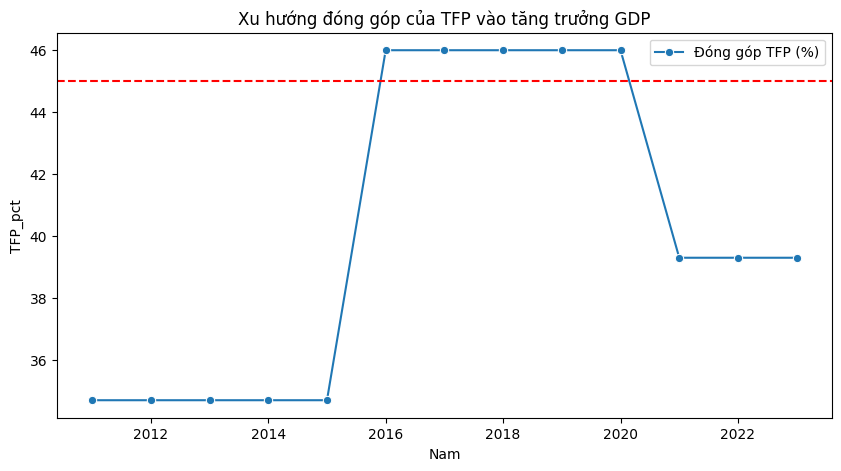

In [3]:
tfp_df = pd.read_csv(r'../data/processed/tfp_contribution_processed.csv')
plt.figure(figsize=(10, 5))
sns.lineplot(data=tfp_df, x='Nam', y='TFP_pct', marker='o', label='Đóng góp TFP (%)')
plt.axhline(y=45, color='r', linestyle='--', label='Ngưỡng mục tiêu 2030')
plt.title('Xu hướng đóng góp của TFP vào tăng trưởng GDP')
plt.show()

## 4. Tầm nhìn 2030 & Bẫy thu nhập (Forecasting)
Dự báo kịch bản và khả năng vươn tới nhóm thu nhập cao.

Dựa trên mô hình Ensemble (ARIMA + LSTM) tại file `GDP_Forecasting_2030.ipynb`:
- **Kịch bản Cơ sở:** GDP bình quân đầu người đạt ~7,500 USD năm 2030.
- **Kịch bản Lạc quan:** Đạt ~8,200 USD nếu đẩy mạnh số hóa Logistics và Tài chính.
- **Kết luận:** Việt Nam sẽ vượt bẫy thu nhập trung bình thấp và tiến sâu vào nhóm trung bình cao, tạo tiền đề cho mục tiêu High Income 2045.

## 5. Đề xuất Hành động
1. **Logistics:** Giảm chi phí vận tải thông qua TFP digital.
2. **Tài chính:** Tăng hiệu quả phân bổ vốn (Capital efficiency).
3. **Du lịch:** Chuyển dịch từ lượng sang chất (High-value services).